In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, ConfusionMatrixDisplay

In [ ]:
## This code imports Python libraries used for data analysis, preprocessing, visualization, and machine learning. Pandas and NumPy handle data processing, while 
# Matplotlib and Seaborn are used for data visualization. Scikit-learn tools are used to split data, preprocess features, 
# and evaluate the performance of the heart disease prediction model.


In [2]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    return df

In [53]:
df = load_data(filepath='../data/Heart_Disease_Prediction.csv')

In [54]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [55]:
df.shape

(270, 14)

In [56]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [57]:
print(f"Null values: {df.isnull().sum()}")
print(f"Duplicate values: {df.duplicated().sum()}")

Null values: Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64
Duplicate values: 0


In [58]:
df.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease                  str
dtype: object

In [60]:
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
df[['Heart Disease']] = encoder.fit_transform(df[['Heart Disease']]).astype(int)
df['Heart Disease'].head(2)

0    1
1    0
Name: Heart Disease, dtype: int64

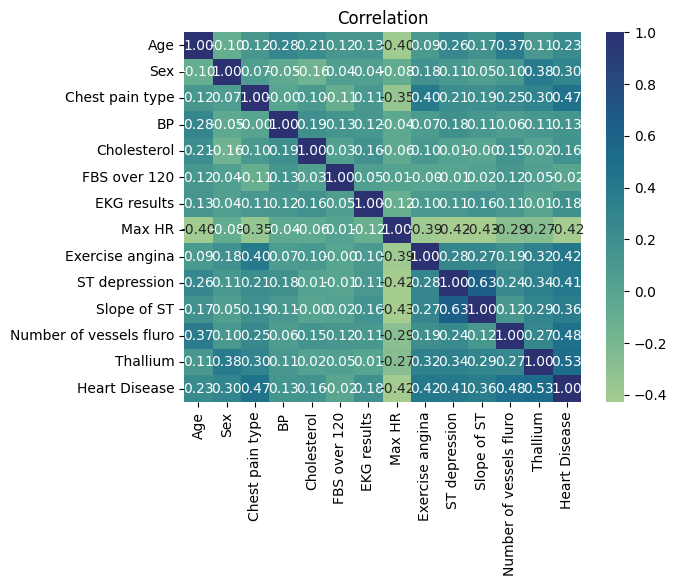

In [62]:
sns.heatmap(df.corr(method="spearman"), annot=True, cmap="crest", fmt=".2f")
plt.title("Correlation")
plt.show()

In [71]:
features = df.drop(columns=['Heart Disease'])
target = df[['Heart Disease']]

In [72]:
x_train, x_test, y_train, y_test = train_test_split(features, target, stratify=target, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((202, 13), (68, 13), (202, 1), (68, 1))

In [73]:
x_tr_scaled = StandardScaler().fit_transform(x_train)
x_te_scaled = StandardScaler().fit_transform(x_test)
x_tr_scaled, x_te_scaled

(array([[-0.04609286,  0.704483  , -0.10050886, ...,  2.34864408,
          0.38767728, -0.86421337],
        [ 0.83021379, -1.41948067,  0.91463061, ..., -0.98066192,
         -0.71529188, -0.86421337],
        [-0.70332285,  0.704483  , -1.11564832, ...,  0.68399108,
         -0.71529188, -0.86421337],
        ...,
        [-1.47009118,  0.704483  , -1.11564832, ...,  0.68399108,
         -0.71529188,  0.68983204],
        [-0.26516953,  0.704483  , -1.11564832, ..., -0.98066192,
          0.38767728, -0.86421337],
        [-0.26516953,  0.704483  ,  0.91463061, ..., -0.98066192,
          0.38767728, -0.86421337]], shape=(202, 13)),
 array([[-1.72256372,  0.64549722,  0.76465394, -0.66370447, -0.7160325 ,
         -0.46291005, -0.90862787, -0.29378281, -0.81150267,  0.10032273,
          0.65722643, -0.70852525,  1.13630232],
        [ 0.28163589,  0.64549722,  0.76465394,  1.17180358,  0.40071543,
         -0.46291005, -0.90862787, -2.3386962 ,  1.23228183,  0.10032273,
          0

In [25]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model = LogisticRegression(penalty=None, random_state=42)
logistic_model.fit(x_tr_scaled, y_train)

In [75]:
logistic_model.coef_


array([[-0.02218123,  1.04705827,  0.75575151,  0.43959406,  0.39699968,
        -0.42473305,  0.01222346, -0.42156472,  0.49165767,  0.23232654,
         0.5367364 ,  1.25632425,  0.52343446]])

In [76]:
y_pred = logistic_model.predict(x_te_scaled)

In [77]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88        38
           1       0.84      0.87      0.85        30

    accuracy                           0.87        68
   macro avg       0.87      0.87      0.87        68
weighted avg       0.87      0.87      0.87        68



Confusion Matrix
[[33  5]
 [ 4 26]]


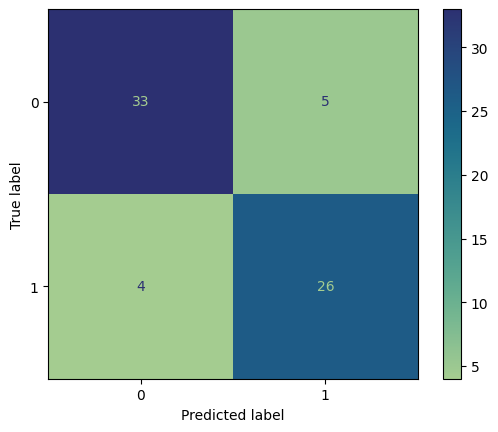

In [78]:
print("Confusion Matrix")
confusion_mat = confusion_matrix(y_true=y_test, y_pred=y_pred)
ConfusionMatrixDisplay(confusion_matrix=confusion_mat).plot(cmap="crest")
print(confusion_mat)

In [79]:
y_score = logistic_model.predict_proba(x_te_scaled)[:,1]

Average Precision Score: 0.897


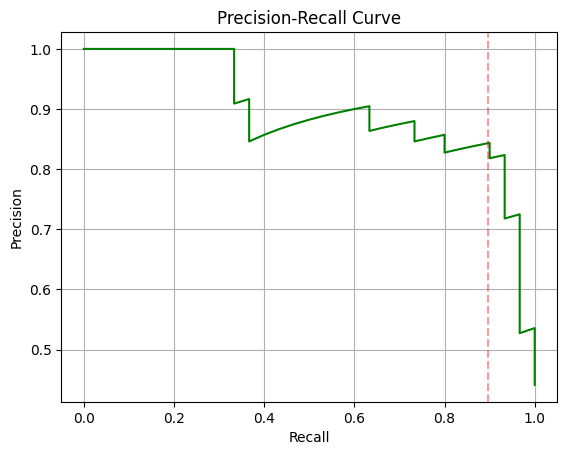

In [80]:
precision, recall, threshold = precision_recall_curve(y_test, y_score)
pr_auc = average_precision_score(y_test, y_score)
plt.plot(recall, precision, color='g')
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axvline(pr_auc, color='r', alpha=0.4, linestyle='--')
print(f"Average Precision Score: {pr_auc:.3f}")

In [ ]:
## This code evaluates the performance of the heart disease prediction model using a Precision-Recall Curve. It calculates precision, recall, and the Average Precision (AP) Score to measure how effectively the model identifies patients with heart disease. The curve is plotted to visualize the trade-off between precision and recall, 
# while the AP score provides a summary of the model's overall classification performance.